# Pandas Quick-Start (pre-class reading for Lecture 2)

**CS1090A / AC209A — read before Lecture 2 (~20 minutes).**

Lecture 2 is about the *ideas* of structured data. This reading is the syntax
floor beneath it: the ten-or-so Pandas moves everything else builds on. Run the
cells as you read — it's self-contained (no files needed).

Everything here is one instance of **four verbs**: *subset*, *aggregate*,
*join*, *transform*. Keep that frame; the lecture leans on it.

In [1]:
import pandas as pd

## 1. The two objects

A **`Series`** is a labeled column. A **`DataFrame`** is a table of them —
rows are records, columns are features, and both carry labels (the row labels
are called the **index**). The most common way to build one by hand is a
list of dictionaries (one dict per row):

In [2]:
screenings = pd.DataFrame([
    {"title": "Jaws",        "theater": "The Brattle",     "year": 1975, "price": 13.0},
    {"title": "Jaws",        "theater": "Somerville",      "year": 1975, "price": 11.5},
    {"title": "Playtime",    "theater": "The Brattle",     "year": 1967, "price": 13.0},
    {"title": "The Thing",   "theater": "Coolidge Corner", "year": 1982, "price": 15.0},
    {"title": "Playtime",    "theater": "The Brattle",     "year": 1967, "price": 13.0},
])
screenings

,title,theater,year,price
0,Jaws,The Brattle,1975,13.0
1,Jaws,Somerville,1975,11.5
2,Playtime,The Brattle,1967,13.0
3,The Thing,Coolidge Corner,1982,15.0
4,Playtime,The Brattle,1967,13.0


## 2. First look, always

Three methods before any analysis: `head()` (what does it look like),
`shape` (how big), `info()` (dtypes and missing values). Make this reflexive.

In [3]:
print(screenings.shape)
screenings.info()

(5, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   title    5 non-null      object 
 1   theater  5 non-null      object 
 2   year     5 non-null      int64  
 3   price    5 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 292.0+ bytes


## 3. Subset: picking columns and rows

- Columns: `df["col"]` (a Series) or `df[["a", "b"]]` (a DataFrame).
- Rows: a **boolean mask** — a true/false Series used as a filter.
- Both at once: `df.loc[mask, ["a", "b"]]`.

In [4]:
old_films = screenings[screenings["year"] < 1980]      # mask -> rows
old_films[["title", "year"]]                            # names -> columns

,title,year
0,Jaws,1975
1,Jaws,1975
2,Playtime,1967
4,Playtime,1967


## 4. Transform: making new columns

Column arithmetic is vectorized — write it like math on whole columns.

In [5]:
screenings["age"] = 2026 - screenings["year"]
screenings["matinee_price"] = screenings["price"] * 0.8
screenings

,title,theater,year,price,age,matinee_price
0,Jaws,The Brattle,1975,13.0,51,10.4
1,Jaws,Somerville,1975,11.5,51,9.2
2,Playtime,The Brattle,1967,13.0,59,10.4
3,The Thing,Coolidge Corner,1982,15.0,44,12.0
4,Playtime,The Brattle,1967,13.0,59,10.4


## 5. Aggregate: `value_counts` and `groupby`

`value_counts()` — the distribution of one column, instantly. `groupby` —
*split* rows into groups, *apply* a statistic, *combine* the results.

In [6]:
screenings["theater"].value_counts()

theater
The Brattle        3
Somerville         1
Coolidge Corner    1
Name: count, dtype: int64

In [7]:
screenings.groupby("theater")["price"].mean()

theater
Coolidge Corner    15.0
Somerville         11.5
The Brattle        13.0
Name: price, dtype: float64

## 6. Join: `merge`

Combine two tables on a shared key. `how="left"` keeps every row of the
left table; keys with no match get `NaN`. **Always check the row count after
a merge** — it's the easiest place for silent errors to enter.

In [8]:
capacity = pd.DataFrame({
    "theater": ["The Brattle", "Coolidge Corner"],
    "seats": [230, 440],
})

merged = screenings.merge(capacity, on="theater", how="left")
assert len(merged) == len(screenings)   # the habit
merged

,title,theater,year,price,age,matinee_price,seats
0,Jaws,The Brattle,1975,13.0,51,10.4,230.0
1,Jaws,Somerville,1975,11.5,51,9.2,NaN
2,Playtime,The Brattle,1967,13.0,59,10.4,230.0
3,The Thing,Coolidge Corner,1982,15.0,44,12.0,440.0
4,Playtime,The Brattle,1967,13.0,59,10.4,230.0


Note Somerville's `NaN` seats: a left-join keeps the row and marks the missing
match. `NaN` is Pandas' missing-value marker; `df.isna().sum()` counts them
per column.

## 7. Dtypes: make columns honest

CSV files carry no types — everything can arrive as strings (`object`). Two
converters you'll use constantly: `pd.to_datetime` and `astype`.

In [9]:
dates = pd.Series(["2026-10-30", "2026-10-31", "2026-11-01"])
dates = pd.to_datetime(dates)
dates.dt.day_name()          # real datetimes unlock the .dt toolbox

0      Friday
1    Saturday
2      Sunday
dtype: object

## 8. Sort, plot, save

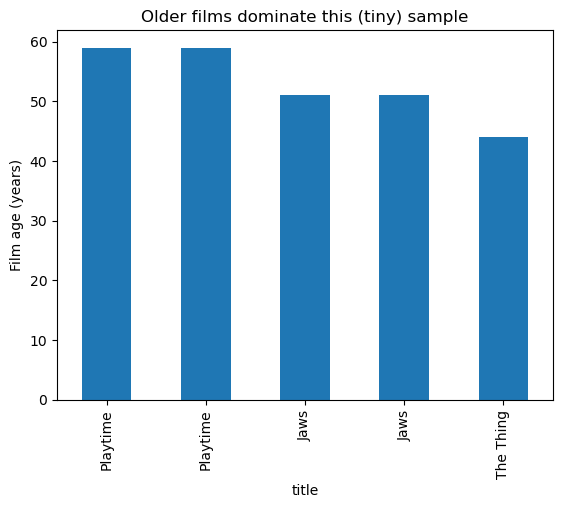

In [10]:
screenings.sort_values("year").plot(x="title", y="age", kind="bar",
                                    legend=False, ylabel="Film age (years)",
                                    title="Older films dominate this (tiny) sample");

In [11]:
screenings.to_csv("quickstart_out.csv", index=False)   # ...and read_csv to load
pd.read_csv("quickstart_out.csv").dtypes               # note: dtypes reset -- lecture explains

title             object
theater           object
year               int64
price            float64
age                int64
matinee_price    float64
dtype: object

## The map

| Verb | The moves you just made |
|---|---|
| **subset** | `df["col"]`, boolean masks, `.loc` |
| **transform** | column arithmetic, `to_datetime`, `astype` |
| **aggregate** | `value_counts`, `groupby(...).mean()` |
| **join** | `merge(..., how="left")` + the row-count check |

That's the floor. Lecture 2 builds the mental models (what a DataFrame *is*,
views vs. copies, why dtypes and file formats matter); Section 2 gives you
reps on real survey data; the official
[10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
is the reference when you need more syntax.